# Speeding up the rendering of large data

`spatialdata-plot` is built to stay responsive on large datasets. This example shows the two
mechanisms that make that possible and how to steer them:

1. **Images / labels** — automatic rasterization of single-scale rasters and automatic scale
   selection for multi-scale rasters, controlled with `dpi`, `figsize`, and the `scale` argument.
2. **Shapes / points** — an optional `datashader` backend (`method="datashader"`) that overtakes
   the default `matplotlib` backend once you render enough objects.

The image sections use the cached `squidpy` Visium H&E mouse-brain dataset (its `hne` image is
multi-scale); the backend benchmarks use small synthetic `SpatialData` objects. Nothing extra
needs downloading.

**Dataset**: a Visium H&E mouse-brain section, loaded by `squidpy.datasets.visium_hne_sdata()` from
the scverse example-data host (cached after the first download).

**Credit**: adapted from the [`speed_up_illustration`] notebook in `spatialdata-notebooks` by
[@Sonja-Stockhaus] and the `spatialdata-plot` team.

[`speed_up_illustration`]: https://github.com/scverse/spatialdata-notebooks/blob/main/notebooks/examples/speed_up_illustration.ipynb
[@Sonja-Stockhaus]: https://github.com/Sonja-Stockhaus

In [1]:
import timeit
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import squidpy as sq
from geopandas import GeoDataFrame
from shapely.affinity import translate
from shapely.geometry import MultiPolygon, Polygon
from spatialdata import SpatialData
from spatialdata.models import Image2DModel, PointsModel, ShapesModel

import spatialdata_plot  # noqa: F401  (registers the .pl accessor)

warnings.filterwarnings("ignore")

# Keep inline figure sizes (and the committed notebook) small; cells that pass an
# explicit `dpi=` to pl.show() still override this for their lesson.
mpl.rcParams["figure.dpi"] = 80

In [2]:
sdata = sq.datasets.visium_hne_sdata()
sdata

INFO     Loading existing dataset from data/spatialdata/visium_hne_sdata.zarr                                      


SpatialData object, with associated Zarr store: /Users/tim.treis/Documents/GitHub/spatialdata-plot-notebooks/examples/data/spatialdata/visium_hne_sdata.zarr
├── Images
│     └── 'hne': DataTree[cyx] (3, 11757, 11291), (3, 5878, 5645), (3, 2939, 2822), (3, 1469, 1411)
├── Shapes
│     └── 'spots': GeoDataFrame shape: (2688, 2) (2D shapes)
└── Tables
      └── 'adata': AnnData (2688, 18078)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), spots (Shapes)

## 1 Single-scale images

A single-scale image is one image on one grid. A multi-scale image bundles several single-scale
images of the *same* picture at decreasing resolutions; rendering one always starts by picking a
single scale, after which it behaves exactly like a single-scale image.

The `hne` image is multi-scale, so to demonstrate single-scale behaviour we pull one of its scales
out into a standalone single-scale image.

In [3]:
single = Image2DModel.parse(sdata["hne"]["scale1"]["image"].data, dims=("c", "y", "x"))
sdata["hne_singlescale"] = single

### 1.1 Default behaviour

When the image is larger than the rendering device, it is automatically rasterized (downsampled)
before drawing. Rendering the full-resolution pixels would not look any better than the device can
display, but would be much slower. A heuristic over image extent, `dpi`, and figure size decides
whether rasterization is needed.

CPU times: user 2.79 s, sys: 1.78 s, total: 4.57 s
Wall time: 3.59 s


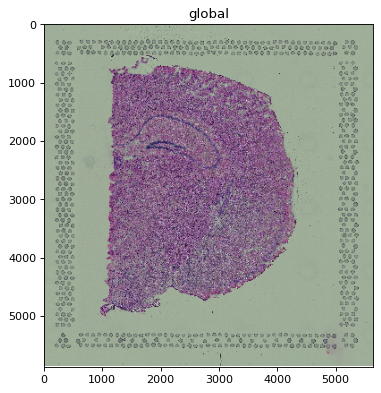

In [4]:
%%time
sdata.pl.render_images("hne_singlescale").pl.show()
# larger than the rendering device -> automatically rasterized before rendering

### 1.2 Options

`dpi` and `figsize` (on `pl.show()`) feed the same heuristic, so they change *whether* and *how far*
the image is rasterized. A higher `dpi` means more device pixels, so less downsampling.

CPU times: user 2.92 s, sys: 1.79 s, total: 4.71 s
Wall time: 3.67 s


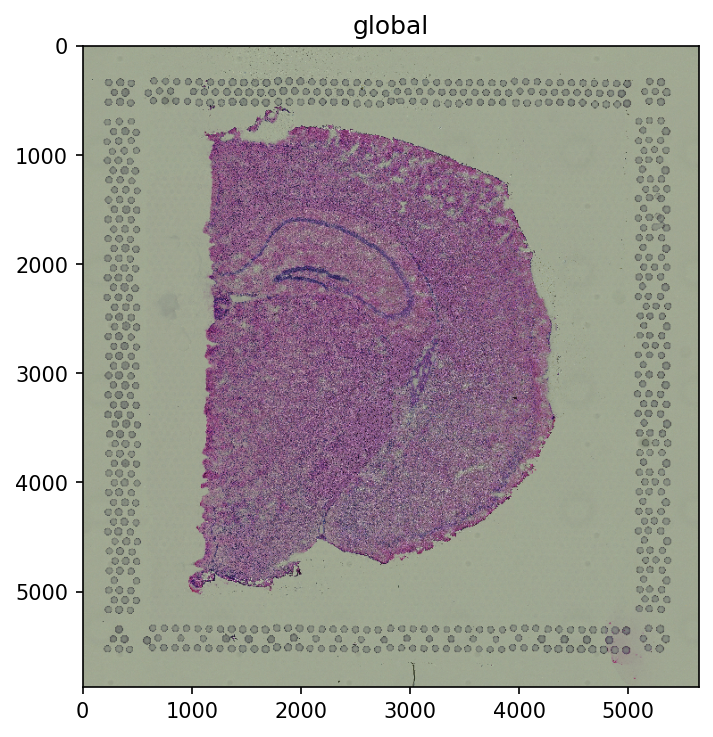

In [5]:
%%time
sdata.pl.render_images("hne_singlescale").pl.show(dpi=150)

To switch rasterization off entirely, pass `scale="full"` to `pl.render_images()` (or
`pl.render_labels()`). The full-resolution image is then drawn as-is — fine here, but slow for very
large images (see the multi-scale section for a more dramatic case).

CPU times: user 3.75 s, sys: 2.14 s, total: 5.89 s
Wall time: 4.72 s


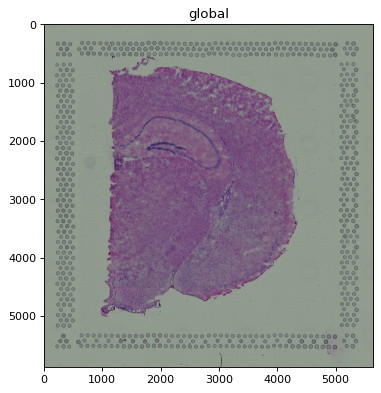

In [6]:
%%time
sdata.pl.render_images("hne_singlescale", scale="full").pl.show()

## 2 Multi-scale images

### 2.1 Default behaviour

By default the scale that best fits the rendering device is selected automatically, then treated
like a single-scale image (rasterized further if still necessary). For `hne` at default size this
picks one of the lower-resolution scales.

CPU times: user 361 ms, sys: 126 ms, total: 487 ms
Wall time: 407 ms


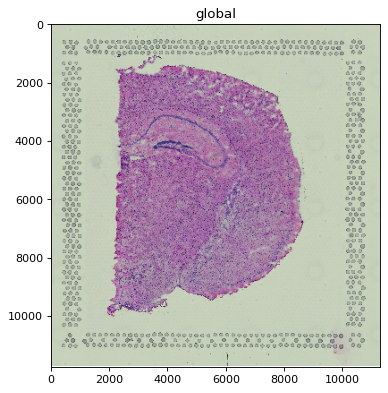

In [7]:
%%time
sdata.pl.render_images("hne").pl.show()
# a low-resolution scale is selected automatically

### 2.2 Options

`dpi` and `figsize` also drive scale selection: a larger figure or higher `dpi` pulls in a
higher-resolution scale. When the "optimal" resolution falls between two stored scales, the
higher-resolution one is selected and rasterized down if needed (otherwise the result would be
coarser than requested).

CPU times: user 604 ms, sys: 127 ms, total: 731 ms
Wall time: 646 ms


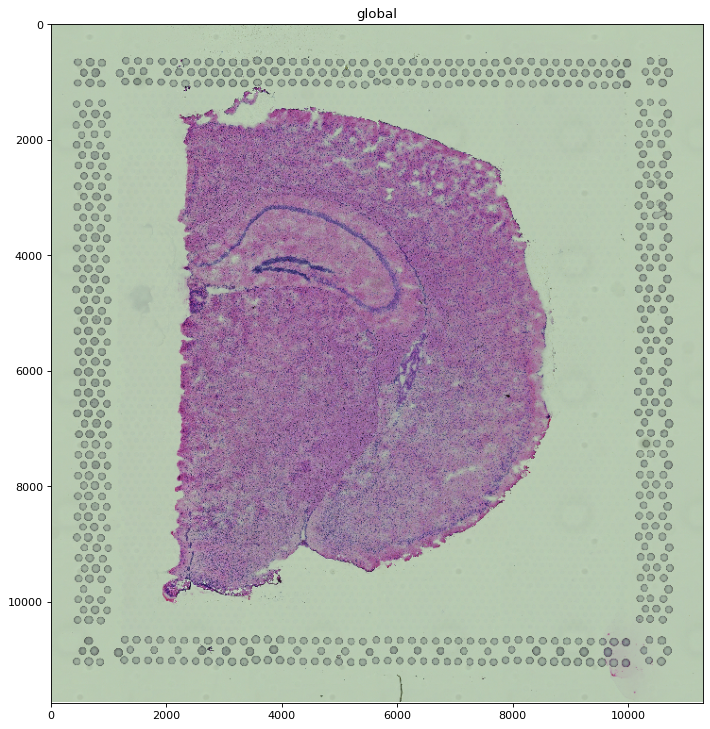

In [8]:
%%time
sdata.pl.render_images("hne").pl.show(figsize=(9.0, 9.0))
# a higher-resolution scale is selected automatically

You can also pin a specific scale with the `scale` argument. When you do, no rasterization is added
unless you *also* set `dpi`/`figsize` on `pl.show()`.

CPU times: user 15.5 s, sys: 9.56 s, total: 25.1 s
Wall time: 20.4 s


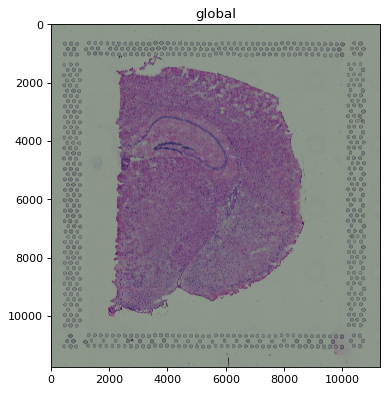

In [9]:
%%time
sdata.pl.render_images("hne", scale="scale0").pl.show()

You can force the highest-resolution scale with `scale="full"`, which skips rasterization entirely.
On a sufficiently large image this is the slow extreme and can even exhaust memory; for this dataset
the full `hne` image is small enough that the difference is minor, so we describe it here rather than
render it.

## 3 Datashader backend for shapes and points

For vector geometry, `spatialdata-plot` can render with either `matplotlib` (the default) or
[`datashader`](https://datashader.org/) via `method="datashader"`. For shapes, `matplotlib` wins for
small collections and `datashader` wins once there are many objects; for points the advantage
reverses. Below we locate the crossover for polygons, multi-polygons, and circles, then for points.

In [10]:
RNG = np.random.default_rng(seed=42)


def generate_shapes(n: int, extent: int = 10_000, multi: bool = False) -> GeoDataFrame:
    q = extent // 4
    shapes = []
    for _ in range(n):
        x, y = RNG.uniform(0, extent), RNG.uniform(0, extent)
        poly = Polygon(
            [
                (x + RNG.uniform(0, q), y + RNG.uniform(0, q)),
                (x + RNG.uniform(0, q), y),
                (x, y + RNG.uniform(0, q)),
            ]
        )
        shapes.append(MultiPolygon([poly, translate(poly, xoff=q, yoff=q)]) if multi else poly)
    return GeoDataFrame({"geometry": shapes})


def make_sdata(to_plot: str, n: int, extent: int = 10_000) -> SpatialData:
    # Only build the element being benchmarked -- rendering never touches anything else.
    if to_plot == "points":
        df = pd.DataFrame(RNG.random((n, 2)) * extent, columns=["x", "y"])
        return SpatialData(points={"points": PointsModel.parse(df)})
    if to_plot == "circles":
        coords = RNG.random((n, 2)) * extent
        return SpatialData(shapes={"circles": ShapesModel.parse(coords, geometry=0, radius=10)})
    gdf = generate_shapes(n, extent, multi=to_plot == "multipolygons")
    return SpatialData(shapes={to_plot: ShapesModel.parse(gdf)})

In [11]:
def benchmark(to_plot: str, counts: list[int], repeat: int = 5) -> pd.DataFrame:
    render_name = "render_points" if to_plot == "points" else "render_shapes"

    # One-time warmup so numba JIT / datashader setup isn't charged to the first timed run.
    warm = getattr(make_sdata(to_plot, max(counts[0], 10)).pl, render_name)
    warm(to_plot, method="matplotlib").pl.show()
    warm(to_plot, method="datashader").pl.show()
    plt.close("all")

    results = []
    for n in counts:
        render = getattr(make_sdata(to_plot, n).pl, render_name)
        run = lambda m: render(to_plot, method=m).pl.show()  # noqa: B023, E731
        mpl_times = timeit.repeat(lambda: run("matplotlib"), number=1, repeat=repeat)  # noqa: B023
        ds_times = timeit.repeat(lambda: run("datashader"), number=1, repeat=repeat)  # noqa: B023
        plt.close("all")  # don't let figures accumulate across counts
        results.extend((n, a, b) for a, b in zip(mpl_times, ds_times))
    return pd.DataFrame(results, columns=["object_num", "mpl_time", "ds_time"])


def crossover(medians: pd.DataFrame) -> int | None:
    """Object count where the faster backend switches, interpolated from the medians.

    Detects a crossing in either direction (datashader overtaking matplotlib for shapes, or
    matplotlib overtaking datashader for points) and returns the last one. None if they never cross.
    """
    m = medians.sort_values("object_num")
    x = np.log10(m["object_num"].to_numpy())
    diff = (m["mpl_time"] - m["ds_time"]).to_numpy()  # > 0 => datashader faster
    cross = None
    for i in range(1, len(diff)):
        if (diff[i - 1] <= 0 < diff[i]) or (diff[i - 1] >= 0 > diff[i]):
            t = -diff[i - 1] / (diff[i] - diff[i - 1])
            cross = 10 ** (x[i - 1] + t * (x[i] - x[i - 1]))
    if cross is None:
        return None
    mag = 10 ** (np.floor(np.log10(cross)) - 1)  # round to 2 significant figures for a clean label
    return int(round(cross / mag) * mag)


def visualise_comparison(results: pd.DataFrame, label: str) -> None:
    medians = results.groupby("object_num").median().reset_index()
    _, ax = plt.subplots(figsize=(7, 4))
    ax.plot(medians["object_num"], medians["mpl_time"], color="tab:blue", linestyle="--")
    ax.plot(medians["object_num"], medians["ds_time"], color="tab:orange", linestyle="--")
    ax.scatter(results["object_num"], results["mpl_time"], color="tab:blue", label="matplotlib")
    ax.scatter(results["object_num"], results["ds_time"], color="tab:orange", label="datashader")
    xover = crossover(medians)
    if xover is not None:
        ax.axvline(xover, color="red", linestyle=":", label=f"crossover (~{xover})")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(f"Number of {label}")
    ax.set_ylabel("Rendering time in seconds\n(lower is better)")
    ax.legend(loc="upper left")
    plt.tight_layout()

### 3.1 Polygons

`matplotlib` is faster for small collections; `datashader` takes over once there are many polygons.
The red line marks the crossover measured from this run — its exact location depends on your
hardware.

In [12]:
%%capture
results_polygons = benchmark("polygons", [1, 10, 100, 250, 1_000, 10_000])

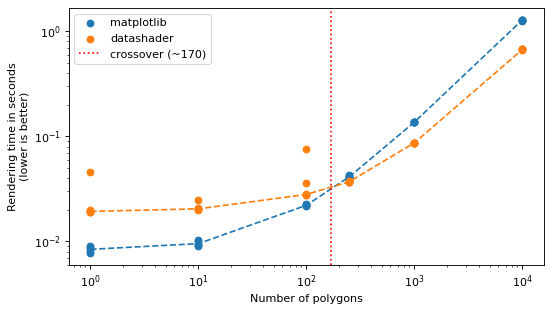

In [13]:
visualise_comparison(results_polygons, "polygons")
plt.show()

### 3.2 Multi-polygons

Multi-polygons behave like polygons; the red line marks the measured crossover.

In [14]:
%%capture
results_multipolygons = benchmark("multipolygons", [1, 10, 100, 225, 1_000, 10_000])

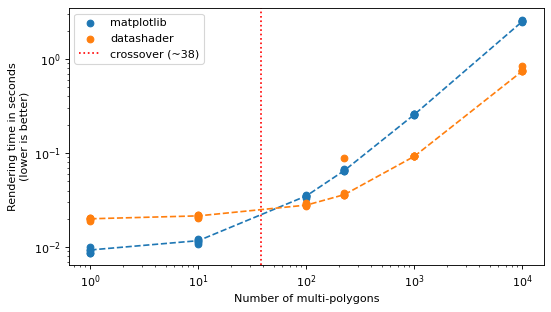

In [15]:
visualise_comparison(results_multipolygons, "multi-polygons")
plt.show()

### 3.3 Circles

Circles behave the same way, with the crossover marked in red.

In [16]:
%%capture
results_circles = benchmark("circles", [1, 10, 100, 250, 1_000, 10_000])

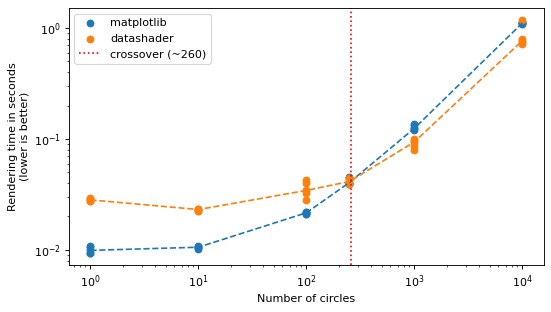

In [17]:
visualise_comparison(results_circles, "circles")
plt.show()

### 3.4 Points

Points invert the shapes story. `datashader` is faster for small point sets, but `matplotlib`
already draws point scatters efficiently and wins at scale: the crossover (marked in red) sits
roughly around 100k points, and out to 10 million `matplotlib` stays ahead. So `datashader` gives no
speed advantage for the large point sets where you would most want it — this was investigated in
[scverse/spatialdata-plot#379]. Choose it for features such as density shading rather than for raw
speed.

[scverse/spatialdata-plot#379]: https://github.com/scverse/spatialdata-plot/issues/379

In [18]:
%%capture
results_points = benchmark("points", [10, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000], repeat=3)

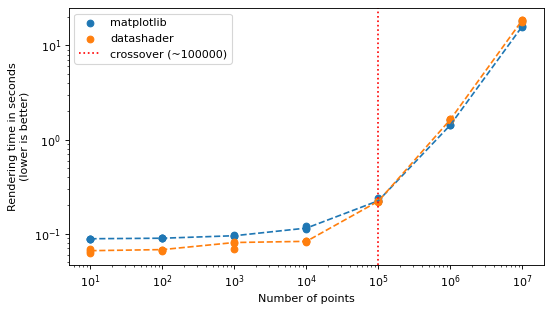

In [19]:
visualise_comparison(results_points, "points")
plt.show()

## For reproducibility

In [20]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import dask
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,scanpy,anndata,squidpy,matplotlib,numpy,pandas,dask,datashader,geopandas,shapely

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_plot: 0.4.0
scanpy          : 1.12.1
anndata         : 0.12.13
squidpy         : 1.8.1
matplotlib      : 3.10.9
numpy           : 2.4.4
pandas          : 2.3.3
dask            : 2026.1.1
datashader      : 0.19.0
geopandas       : 1.1.3
shapely         : 2.1.2

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

